In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


In [14]:
address_df = 'timing_v3.csv'
df = pd.read_csv(address_df)
print(df.shape)
df.head()

(713, 25)


,Z-Height,Elapsed_Time_s,1kcp_1.073_torque_%_rpm_47,2kcp_3.345_torque_%_rpm_15,4kcp_6.603_torque_%_rpm_8,5kcp_5.861_torque_%_rpm_9,8kcp_8.946_torque_%_rpm_5.6,10kcp_9.152_torque_%_rpm_5.5,12.5kcp_14.576_torque_%_rpm_3.5,15kcp_19.036_torque_%_rpm_2.6,...,45kcp_40.820_torque_%_rpm_1.2,50kcp_79.653_torque_%_rpm_0.6,55kcp_48.553_torque_%_rpm_1,60kcp_68.953_torque_%_rpm_0.8,70kcp_87.046_torque_%_rpm_0.5,75kcp_70.730_torque_%_rpm_0.7,80kcp_103.800_torque_%_rpm_0.5,90kcp_102.466_torque_%_rpm_0.5,95kcp_93.400_torque_%_rpm_0.5,100kcp_124.033_torque_%_rpm_0.4
0,-65.9,5.03,37.22,35.52,33.01,34.35,33.67,36.53,35.34,34.60,...,28.25,21.61,25.47,27.28,19.85,22.95,20.46,20.57,19.03,17.37
1,-65.9,10.10,37.28,35.59,33.04,34.46,33.77,36.81,35.49,34.98,...,30.44,27.87,28.16,34.08,26.23,27.58,27.36,27.79,24.79,23.54
2,-65.9,15.07,37.31,35.62,33.02,34.50,33.83,36.91,35.47,35.09,...,30.91,30.75,28.80,36.86,29.78,29.31,31.57,32.29,27.54,27.65
3,-65.9,20.05,37.34,35.66,32.97,34.52,33.85,36.95,35.45,35.17,...,31.03,32.06,29.03,38.03,31.65,29.90,33.91,34.70,28.90,30.07
4,-65.9,25.03,37.36,35.70,32.99,34.54,33.88,37.01,35.39,35.04,...,31.04,32.65,29.10,38.50,32.58,30.14,35.12,35.98,29.54,31.49


In [15]:
# Each column (except 'Z-Height' and 'Elapsed_Time_s') is a torque measurement at a specific rpm
# At each height, the torque is measured at different time intervals as listed in the column 'Elapsed_Time_s'
# For every Height, we want to calculate the average of torque (the value in the column) at
# top 10-percentile of 'Elapsed_Time_s' and use that as the representative torque value for that height.

if 'Elapsed_Time_s' in df.columns:
    torque_cols = [c for c in df.columns if c not in ('Z-Height', 'Elapsed_Time_s')]

    def top10_mean(group):
        threshold = group['Elapsed_Time_s'].quantile(0.90)
        top = group[group['Elapsed_Time_s'] >= threshold]
        return top[torque_cols].mean()

    df = (
        df.groupby('Z-Height', sort=False)
          .apply(top10_mean, include_groups=False)
          .reset_index()
    )

print(df.shape)
df.head()

(31, 24)


,Z-Height,1kcp_1.073_torque_%_rpm_47,2kcp_3.345_torque_%_rpm_15,4kcp_6.603_torque_%_rpm_8,5kcp_5.861_torque_%_rpm_9,8kcp_8.946_torque_%_rpm_5.6,10kcp_9.152_torque_%_rpm_5.5,12.5kcp_14.576_torque_%_rpm_3.5,15kcp_19.036_torque_%_rpm_2.6,20kcp_24.396_torque_%_rpm_2.1,...,45kcp_40.820_torque_%_rpm_1.2,50kcp_79.653_torque_%_rpm_0.6,55kcp_48.553_torque_%_rpm_1,60kcp_68.953_torque_%_rpm_0.8,70kcp_87.046_torque_%_rpm_0.5,75kcp_70.730_torque_%_rpm_0.7,80kcp_103.800_torque_%_rpm_0.5,90kcp_102.466_torque_%_rpm_0.5,95kcp_93.400_torque_%_rpm_0.5,100kcp_124.033_torque_%_rpm_0.4
0,-65.90,37.383333,35.640000,32.613333,34.580000,33.830000,37.076667,34.853333,35.136667,36.043333,...,30.813333,33.170000,29.016667,38.773333,33.746667,30.166667,36.640000,37.723333,30.220000,33.780000
1,-65.92,38.536667,36.526667,32.823333,34.966667,33.840000,37.330000,35.470000,36.140000,36.720000,...,31.236667,33.910000,29.000000,39.560000,34.356667,30.656667,37.400000,38.680000,30.790000,34.570000
2,-65.94,39.490000,37.496667,33.336667,35.016667,34.353333,37.846667,36.180000,37.066667,37.500000,...,31.843333,34.603333,29.053333,40.406667,35.090000,31.223333,38.126667,39.666667,31.450000,35.316667
3,-65.96,40.720000,38.650000,34.046667,35.076667,35.110000,38.340000,37.010000,38.120000,38.536667,...,32.653333,35.406667,29.333333,41.430000,35.976667,31.933333,39.096667,40.820000,32.246667,36.230000
4,-65.98,42.006667,39.786667,34.683333,35.133333,35.946667,38.710000,37.886667,39.070000,39.553333,...,33.316667,36.276667,30.016667,42.546667,36.846667,32.650000,40.023333,41.896667,32.986667,37.136667


In [16]:
# Then we want to calculate the rotational drag (torque / rpm) for each column and plot it against Z-Height.
# Exclude the column Z-Height to have just torque data
X = df.drop(columns=['Z-Height'])

# Consider the title of each column as a coded value for the viscosity and rpm
# For example, if the column is named "1kcp_1.073_torque_%_rpm_47", we can extract the viscosity and rpm from the name
def extract_features(column_name):
    parts = column_name.split('_')
    viscosity_kcp = float(parts[1])  # Extract viscosity
    rpm = float(parts[5])  # Extract rpm

    return viscosity_kcp, rpm

# Calculate rotational drag for all columns (torque / rpm) element-wise
# Resulting DataFrame has the same dimensions as df
updated_df = pd.DataFrame(index=df.index)
updated_df['Height'] = df['Z-Height']

for column in X.columns:
    viscosity_kcp, rpm = extract_features(column)
    updated_df[column] = X[column] / rpm

# Show the new DataFrame
updated_df.head()

,Height,1kcp_1.073_torque_%_rpm_47,2kcp_3.345_torque_%_rpm_15,4kcp_6.603_torque_%_rpm_8,5kcp_5.861_torque_%_rpm_9,8kcp_8.946_torque_%_rpm_5.6,10kcp_9.152_torque_%_rpm_5.5,12.5kcp_14.576_torque_%_rpm_3.5,15kcp_19.036_torque_%_rpm_2.6,20kcp_24.396_torque_%_rpm_2.1,...,45kcp_40.820_torque_%_rpm_1.2,50kcp_79.653_torque_%_rpm_0.6,55kcp_48.553_torque_%_rpm_1,60kcp_68.953_torque_%_rpm_0.8,70kcp_87.046_torque_%_rpm_0.5,75kcp_70.730_torque_%_rpm_0.7,80kcp_103.800_torque_%_rpm_0.5,90kcp_102.466_torque_%_rpm_0.5,95kcp_93.400_torque_%_rpm_0.5,100kcp_124.033_torque_%_rpm_0.4
0,-65.90,0.795390,2.376000,4.076667,3.842222,6.041071,6.741212,9.958095,13.514103,17.163492,...,25.677778,55.283333,29.016667,48.466667,67.493333,43.095238,73.280000,75.446667,60.440000,84.450000
1,-65.92,0.819929,2.435111,4.102917,3.885185,6.042857,6.787273,10.134286,13.900000,17.485714,...,26.030556,56.516667,29.000000,49.450000,68.713333,43.795238,74.800000,77.360000,61.580000,86.425000
2,-65.94,0.840213,2.499778,4.167083,3.890741,6.134524,6.881212,10.337143,14.256410,17.857143,...,26.536111,57.672222,29.053333,50.508333,70.180000,44.604762,76.253333,79.333333,62.900000,88.291667
3,-65.96,0.866383,2.576667,4.255833,3.897407,6.269643,6.970909,10.574286,14.661538,18.350794,...,27.211111,59.011111,29.333333,51.787500,71.953333,45.619048,78.193333,81.640000,64.493333,90.575000
4,-65.98,0.893759,2.652444,4.335417,3.903704,6.419048,7.038182,10.824762,15.026923,18.834921,...,27.763889,60.461111,30.016667,53.183333,73.693333,46.642857,80.046667,83.793333,65.973333,92.841667


In [17]:
# Trim the part of data in each column where it hits the bottom or the top
# Set each value to the Height threshold to keep; data outside [trim_bot, trim_top] will be removed

trim_values = {col: None for col in updated_df.columns if col != 'Height'}
trim_top_values = {col: None for col in updated_df.columns if col != 'Height'}

# --- Manually set BOTTOM trim height per column (data below this is removed) ---
trim_values['1kcp_1.073_torque_%_rpm_47']        = -66.22
trim_values['2kcp_3.345_torque_%_rpm_15']        = -66.22
trim_values['4kcp_6.603_torque_%_rpm_8']         = -66.34
trim_values['5kcp_5.861_torque_%_rpm_9']         = -66.34
trim_values['8kcp_8.946_torque_%_rpm_5.6']       = -66.30
trim_values['10kcp_9.152_torque_%_rpm_5.5']      = -66.32
trim_values['12.5kcp_14.576_torque_%_rpm_3.5']   = -66.26
trim_values['15kcp_19.036_torque_%_rpm_2.6']     = -66.32
trim_values['20kcp_24.396_torque_%_rpm_2.1']     = -66.24
trim_values['25kcp_22.760_torque_%_rpm_2.2']     = -66.36
trim_values['30kcp_31.903_torque_%_rpm_1.7']     = -66.26
trim_values['35kcp_63.253_torque_%_rpm_0.8']     = -66.24
trim_values['40kcp_62.756_torque_%_rpm_0.8']     = -66.24
trim_values['45kcp_40.820_torque_%_rpm_1.2']     = -66.34
trim_values['50kcp_79.653_torque_%_rpm_0.6']     = -66.24
trim_values['55kcp_48.553_torque_%_rpm_1']       = -66.44
trim_values['60kcp_68.953_torque_%_rpm_0.8']     = -66.24
trim_values['70kcp_87.046_torque_%_rpm_0.5']     = -66.26
trim_values['75kcp_70.730_torque_%_rpm_0.7']     = -66.34
trim_values['80kcp_103.800_torque_%_rpm_0.5']    = -66.26
trim_values['90kcp_102.466_torque_%_rpm_0.5']    = -66.24
trim_values['95kcp_93.400_torque_%_rpm_0.5']     = -66.32
trim_values['100kcp_124.033_torque_%_rpm_0.4']   = -66.24

# --- Manually set TOP trim height per column (data above this is removed) ---
trim_top_values['1kcp_1.073_torque_%_rpm_47']        = None
trim_top_values['2kcp_3.345_torque_%_rpm_15']        = None
trim_top_values['4kcp_6.603_torque_%_rpm_8']         = -65.92
trim_top_values['5kcp_5.861_torque_%_rpm_9']         = -66.00
trim_top_values['8kcp_8.946_torque_%_rpm_5.6']       = -65.92
trim_top_values['10kcp_9.152_torque_%_rpm_5.5']      = None
trim_top_values['12.5kcp_14.576_torque_%_rpm_3.5']   = None
trim_top_values['15kcp_19.036_torque_%_rpm_2.6']     = -66.10
trim_top_values['20kcp_24.396_torque_%_rpm_2.1']     = None
trim_top_values['25kcp_22.760_torque_%_rpm_2.2']     = None
trim_top_values['30kcp_31.903_torque_%_rpm_1.7']     = None
trim_top_values['35kcp_63.253_torque_%_rpm_0.8']     = None
trim_top_values['40kcp_62.756_torque_%_rpm_0.8']     = None
trim_top_values['45kcp_40.820_torque_%_rpm_1.2']     = None
trim_top_values['50kcp_79.653_torque_%_rpm_0.6']     = None
trim_top_values['55kcp_48.553_torque_%_rpm_1']       = -65.94
trim_top_values['60kcp_68.953_torque_%_rpm_0.8']     = None
trim_top_values['70kcp_87.046_torque_%_rpm_0.5']     = None
trim_top_values['75kcp_70.730_torque_%_rpm_0.7']     = None
trim_top_values['80kcp_103.800_torque_%_rpm_0.5']    = None
trim_top_values['90kcp_102.466_torque_%_rpm_0.5']    = None
trim_top_values['95kcp_93.400_torque_%_rpm_0.5']     = None
trim_top_values['100kcp_124.033_torque_%_rpm_0.4']   = None

print("Bottom trim set for", sum(v is not None for v in trim_values.values()), "/", len(trim_values), "columns")
print("Top    trim set for", sum(v is not None for v in trim_top_values.values()), "/", len(trim_top_values), "columns")


Bottom trim set for 23 / 23 columns
Top    trim set for 5 / 23 columns


In [18]:
# Trim the data based on the specified trim values
# Re-run safe: always restores from backup before applying trim
# To reset the backup (e.g. after re-running cell 4), restart the kernel and re-run all cells

if '_updated_df_raw' not in globals():
    _updated_df_raw = updated_df.copy()

updated_df = _updated_df_raw.copy()

# Apply bottom trim: set NaN where Height < bottom threshold
for column, trim_bot in trim_values.items():
    if trim_bot is not None and column in updated_df.columns:
        updated_df[column] = updated_df[column].where(updated_df['Height'] >= trim_bot)

# Apply top trim: set NaN where Height > top threshold
for column, trim_top in trim_top_values.items():
    if trim_top is not None and column in updated_df.columns:
        updated_df[column] = updated_df[column].where(updated_df['Height'] <= trim_top)

trimmed_counts = updated_df.isna().sum()
trimmed_counts = trimmed_counts[trimmed_counts > 0]
print(f"Trimmed (NaN) rows per column:\n{trimmed_counts.to_string()}")
print("\nData shape after trimming:", updated_df.shape)

Trimmed (NaN) rows per column:
1kcp_1.073_torque_%_rpm_47         14
2kcp_3.345_torque_%_rpm_15         14
4kcp_6.603_torque_%_rpm_8           9
5kcp_5.861_torque_%_rpm_9          13
8kcp_8.946_torque_%_rpm_5.6        11
10kcp_9.152_torque_%_rpm_5.5        9
12.5kcp_14.576_torque_%_rpm_3.5    12
15kcp_19.036_torque_%_rpm_2.6      19
20kcp_24.396_torque_%_rpm_2.1      13
25kcp_22.760_torque_%_rpm_2.2       7
30kcp_31.903_torque_%_rpm_1.7      12
35kcp_63.253_torque_%_rpm_0.8      13
40kcp_62.756_torque_%_rpm_0.8      13
45kcp_40.820_torque_%_rpm_1.2       8
50kcp_79.653_torque_%_rpm_0.6      13
55kcp_48.553_torque_%_rpm_1         5
60kcp_68.953_torque_%_rpm_0.8      13
70kcp_87.046_torque_%_rpm_0.5      12
75kcp_70.730_torque_%_rpm_0.7       8
80kcp_103.800_torque_%_rpm_0.5     12
90kcp_102.466_torque_%_rpm_0.5     13
95kcp_93.400_torque_%_rpm_0.5       9
100kcp_124.033_torque_%_rpm_0.4    13

Data shape after trimming: (31, 24)


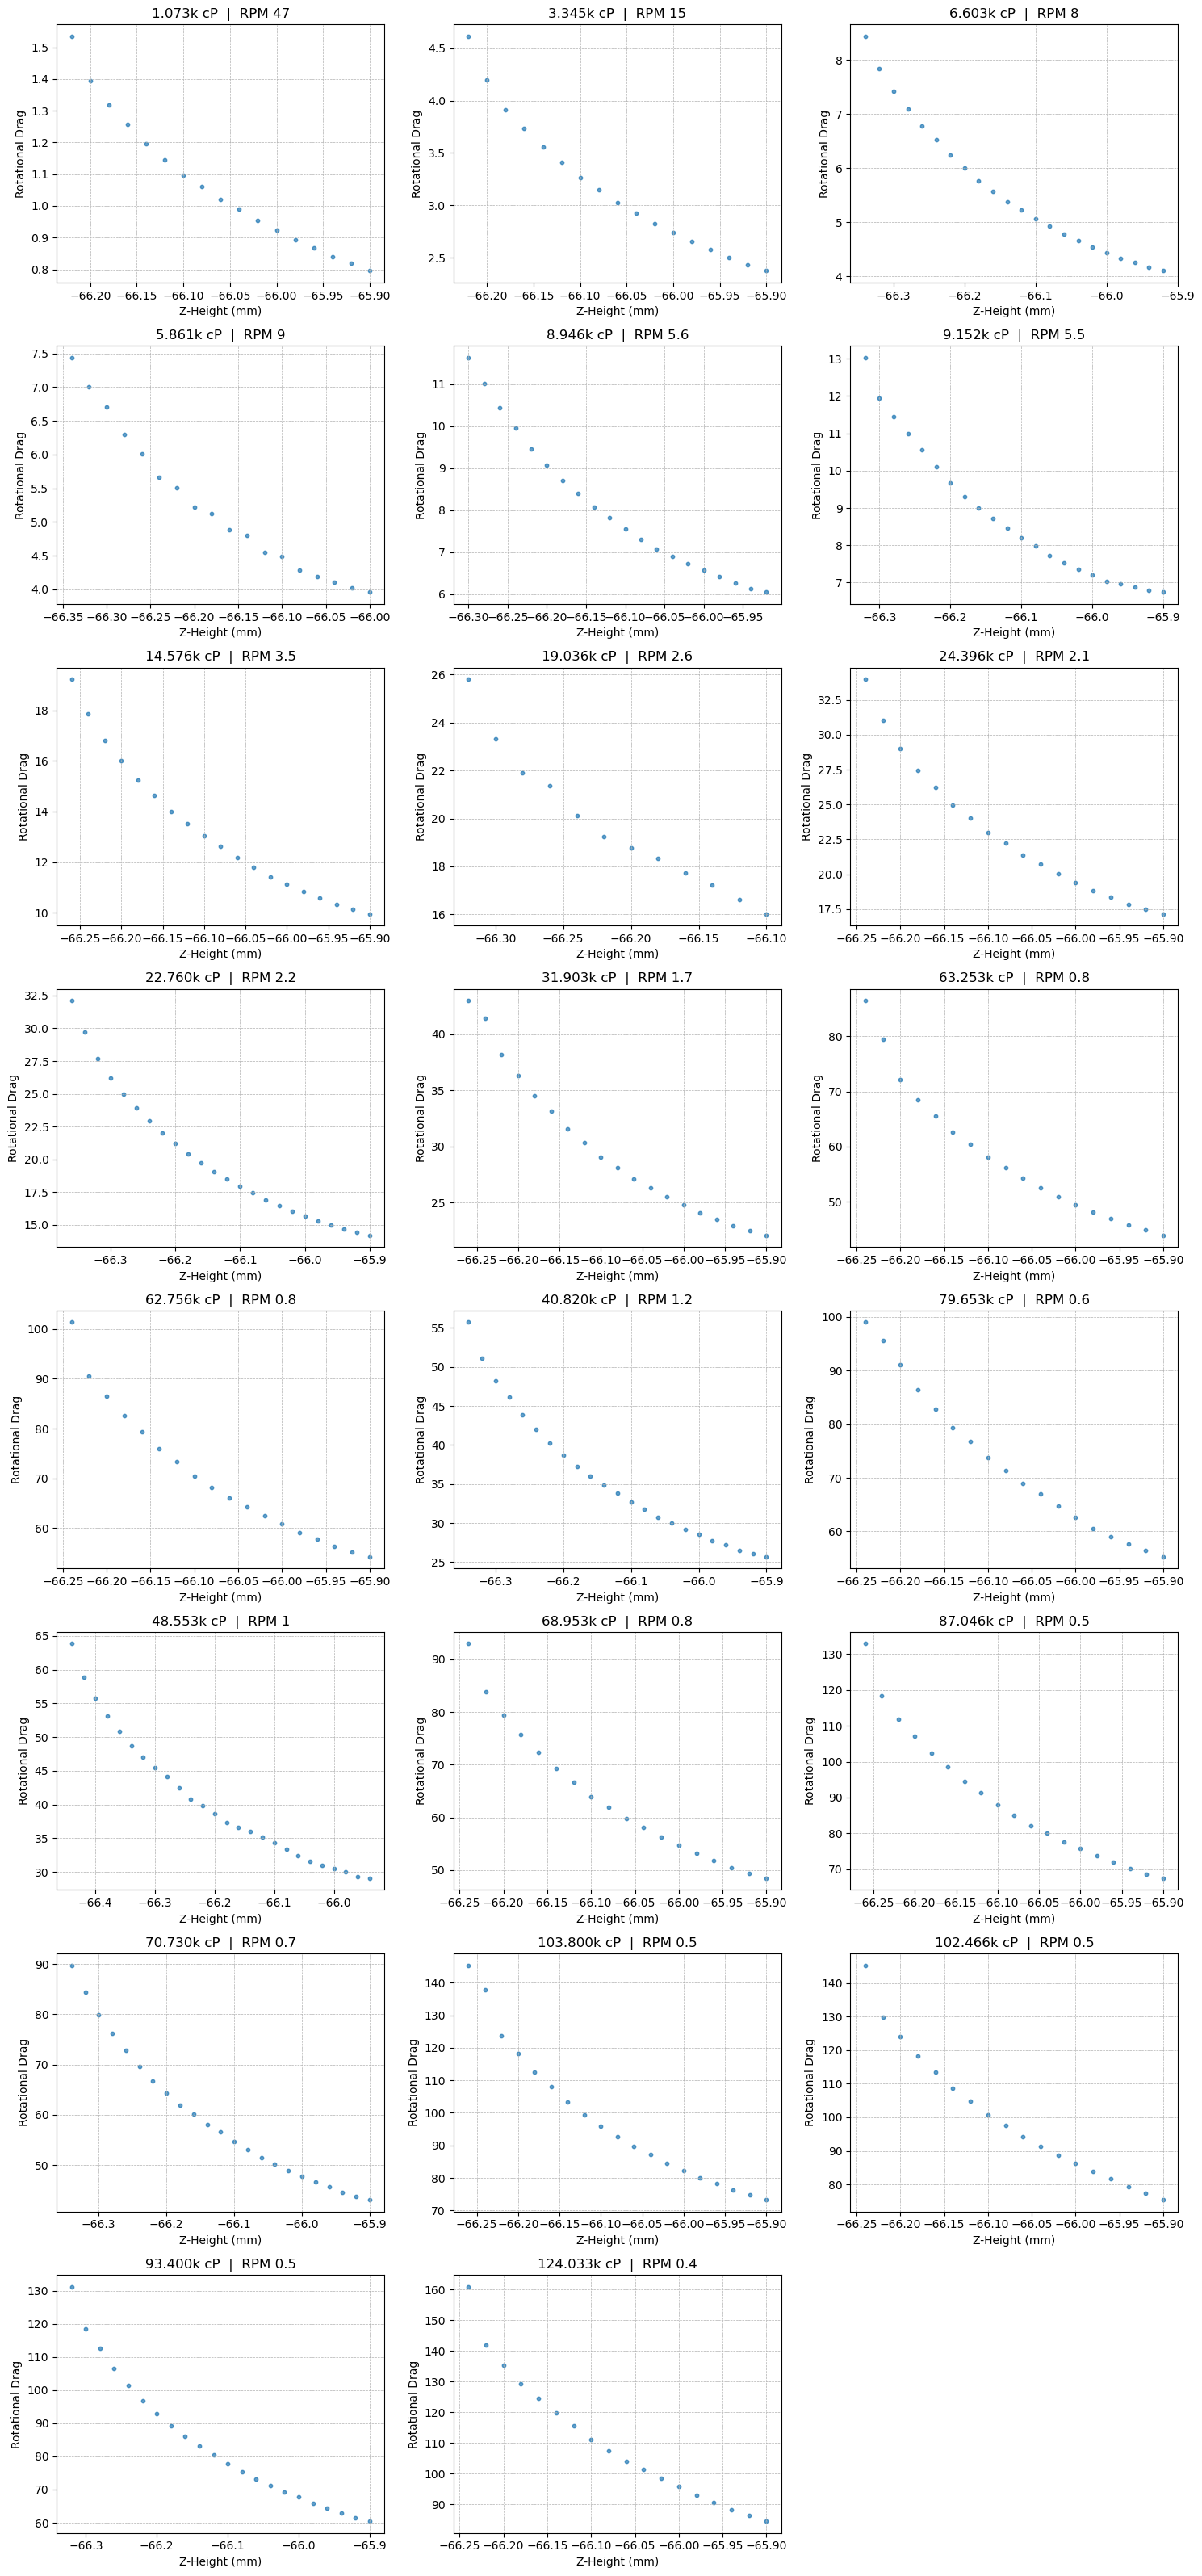

In [19]:
# Plotting the data to visualize the relationship between Z-Height and rotational drag for a specific viscosity

drag_cols = [c for c in updated_df.columns if c != 'Height']
height = updated_df['Height'].values

n_cols_plot = 3
n_rows_plot = int(np.ceil(len(drag_cols) / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(5 * n_cols_plot, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(drag_cols):
    ax = axes[i]
    ax.scatter(height, updated_df[col].values, s=10, alpha=0.7)
    parts = col.split('_')
    viscosity = parts[1]
    rpm = parts[5]
    ax.set_title(f'{viscosity}k cP  |  RPM {rpm}')
    ax.set_xlabel('Z-Height (mm)')
    ax.set_ylabel('Rotational Drag')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Hide unused axes if total columns don't fill the grid
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


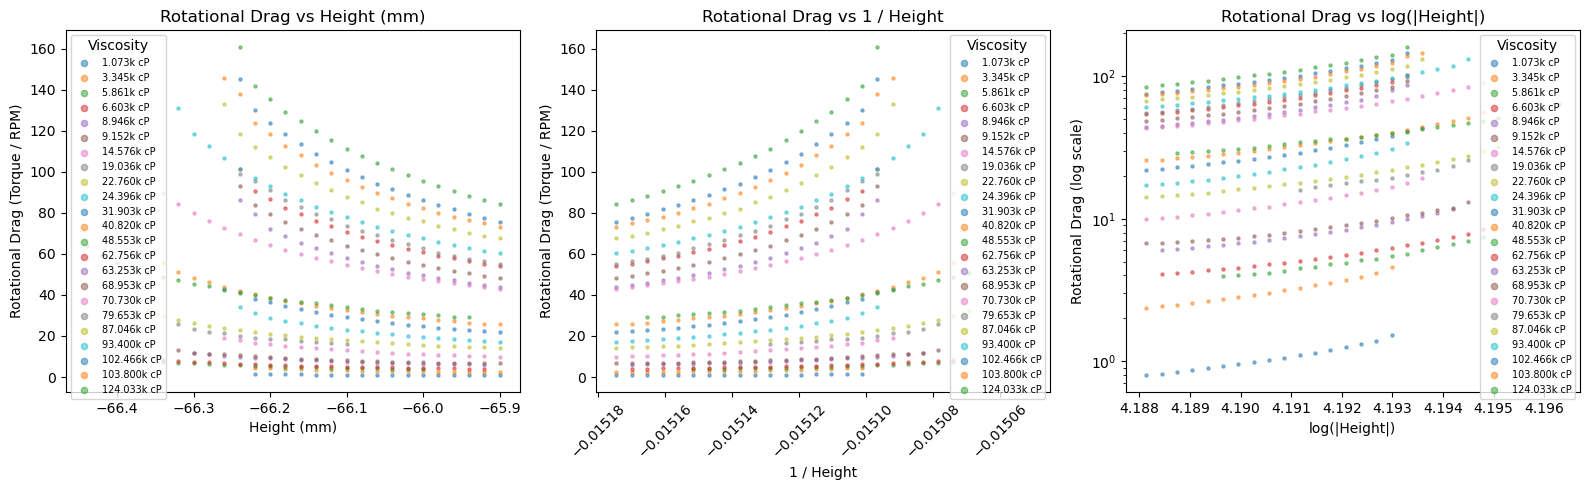

In [20]:
# Gather all rotational drag columns (everything except 'Height')
drag_cols = [c for c in updated_df.columns if c != 'Height']
height = updated_df['Height'].values

# Group columns by viscosity (decoded from column name)
# e.g. "2kcp_3.345_torque_%_rpm_15" → label "3.345k cP"
from itertools import groupby

def decode_label(column_name):
    parts = column_name.split('_')
    return f"{parts[1]}k cP"

# Build a dict: label → list of columns sharing that viscosity
groups = {}
for col in drag_cols:
    label = decode_label(col)
    groups.setdefault(label, []).append(col)

# Sort groups by numeric viscosity value for consistent legend ordering
groups = dict(sorted(groups.items(), key=lambda item: float(item[0].split('k')[0])))

# 3 forms of Height for x-axis; last subplot also uses log y-axis
x_form_defs = {
    'Height (mm)':  (lambda h: h,                    False),
    '1 / Height':   (lambda h: 1 / h,                False),
    'log(|Height|)': (lambda h: np.log(np.abs(h)),   True),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (ax, (xlabel, (h_transform, log_y))) in enumerate(zip(axes, x_form_defs.items())):
    x_vals = h_transform(height)
    for label, cols in groups.items():
        drag_values = updated_df[cols].values.flatten()
        x_repeated = np.tile(x_vals, len(cols))
        ax.scatter(x_repeated, drag_values, s=5, alpha=0.5, label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Rotational Drag (Torque / RPM)')
    ax.set_title(f'Rotational Drag vs {xlabel}')
    if log_y:
        ax.set_yscale('log')
        ax.set_ylabel('Rotational Drag (log scale)')
    if i == 1:
        ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Viscosity', markerscale=2, fontsize=7)

plt.tight_layout()
plt.show()
